In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.color import rgb2gray, gray2rgb
import torch
from torch.optim.lr_scheduler import CyclicLR
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors

from config import Config
from model import get_model_instance_segmentation, mrcnn_inference, thresholded_predictions
from neurons import NeuronsDataset, collate_fn, data_transform, train_one_epoch, validate
from neurons import perform_final_evaluation
from utils import ScaleImage, nf_match_neurons_in_binary_masks, normalize_image, vp_load_image
from utils import f1_score
from visualize import apply_masks, draw_boxes
from tqdm import tqdm

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [3]:
"""Main function to run the training pipeline."""
""" Config 
# Paths
    DATASET_PATH = r'/mnt/home/mpaez/ceph/volpy_training_data/'
    MODEL_SAVE_DIR = r'/mnt/home/mpaez/ceph/volpy_models/'

    # Model and Training Hyperparameters
    NUM_CLASSES = 1 + 1  # Background + Neuron
    BATCH_SIZE = 2 
    NUM_EPOCHS = 100
    MAX_LR = 0.005
    BASE_LR = 0.000001
    STEP_SIZE_UP = 3
    STEP_SIZE_DOWN = 7

    # Data Loading, Splitting, and Inference
    # IMAGES_PER_GPU = 2
    RANDOM_SPLIT = False # True for random split, False for fixed split from map below.
    NUM_TEST_RANDOM = 8
    NUM_TORCH_WORKERS = 4 
    DATASET_REGION_MAP = {
            'HPC': [0, 1, 2, 3],
            'L1': [12, 13, 14],
            'TEG': [21],
            'Train': [4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 22, 23]
        }

    INFERENCE_THRESHOLD = 0.5

    # Logging and Saving Frequency
    PRINT_FREQ = 1 
    SAVE_FREQ = 20 
"""

config = Config()
""" Main function to run the training and validation pipeline."""
os.makedirs(config.MODEL_SAVE_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Loading datasets...")
dataset_train = NeuronsDataset(config.DATA_DIR, data_transform(train=True))
dataset_val = NeuronsDataset(config.DATA_DIR, data_transform(train=False))

if config.RANDOM_SPLIT:
    print("Using random split for train/validation sets.")
    indices = list(range(len(dataset_train_instance)))
    np.random.shuffle(indices)
    train_indices = indices[:-config.NUM_TEST_RANDOM]
    val_indices = indices[-config.NUM_TEST_RANDOM:]
else:
    print("Using fixed split based on DATASET_REGION_MAP.")
    train_indices = config.DATASET_REGION_MAP['Train']
    val_indices = [idx for region, inds in config.DATASET_REGION_MAP.items() if region != 'Train' for idx in inds]
    
val_indices_path = os.path.join(config.MODEL_SAVE_DIR, 'validation_indices.npy')
np.save(val_indices_path, val_indices)
print(f"Validation indices for this run have been saved to {val_indices_path}")

dataset_train = torch.utils.data.Subset(dataset_train, train_indices)
dataset_val = torch.utils.data.Subset(dataset_val, val_indices)

data_loader_train = DataLoader(dataset_train, batch_size=config.BATCH_SIZE, shuffle=True,
                                   num_workers=config.NUM_TORCH_WORKERS, collate_fn=collate_fn)
data_loader_val = DataLoader(dataset_val, batch_size=1, shuffle=False,
                                 num_workers=config.NUM_TORCH_WORKERS, collate_fn=collate_fn)


Using device: cuda
Loading datasets...
Using fixed split based on DATASET_REGION_MAP.
Validation indices for this run have been saved to /mnt/home/mpaez/ceph/volpy_models/validation_indices.npy


In [4]:
# Model
model = get_model_instance_segmentation(config.NUM_CLASSES)
model.to(device)
    
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=config.MAX_LR, momentum=0.9, weight_decay=0.0001)
lr_scheduler = CyclicLR(optimizer, base_lr=config.BASE_LR, max_lr=config.MAX_LR,
                            step_size_up=config.STEP_SIZE_UP, step_size_down=config.STEP_SIZE_DOWN,
                            mode="triangular2")

In [5]:
all_train_losses, all_val_losses, all_lrs = [], [], []
print(f"**TRAIN {config.NUM_EPOCHS} epochs. PRINT every {config.PRINT_FREQ} epoch(s). "
          f"SAVE every {config.SAVE_FREQ} epoch(s).**")

for epoch in range(config.NUM_EPOCHS):
    train_loss = train_one_epoch(model, optimizer, data_loader_train, device, epoch)
    val_loss = validate(model, data_loader_val, device, epoch)
    current_lr = optimizer.param_groups[0]["lr"]

    all_train_losses.append(train_loss)
    all_val_losses.append(val_loss)
    all_lrs.append(current_lr)

    lr_scheduler.step()

    if (epoch + 1) % config.PRINT_FREQ == 0:
        print(f"Epoch {epoch+1}/{config.NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}")

    if (epoch + 1) % config.SAVE_FREQ == 0:
        model_path = os.path.join(config.MODEL_SAVE_DIR, f'mrcnn_epoch_{epoch+1}.pt')
        torch.save(model.state_dict(), model_path)
        print(f"\t Model saved to {model_path}")

history = {'train_loss': all_train_losses, 'val_loss': all_val_losses, 'lr': all_lrs}
torch.save(history, os.path.join(config.MODEL_SAVE_DIR, 'volpy_train_history.pt'))
print("\nDONE!")

**TRAIN 100 epochs. PRINT every 1 epoch(s). SAVE every 20 epoch(s).**


Epoch 1 [val]: 100%|██████████| 8/8 [00:00<00:00, 15.59it/s]


Epoch 1/100 | Train Loss: 4.5746, Val Loss: 4.4513, LR: 0.000001


Epoch 2 [val]: 100%|██████████| 8/8 [00:00<00:00, 21.05it/s]


Epoch 2/100 | Train Loss: 2.4146, Val Loss: 2.3027, LR: 0.001667


...

Epoch 98/100 | Train Loss: 0.9421, Val Loss: 1.1742, LR: 0.000005


Epoch 99 [val]: 100%|██████████| 8/8 [00:00<00:00, 20.44it/s]


Epoch 99/100 | Train Loss: 0.9591, Val Loss: 1.2017, LR: 0.000004


Epoch 100 [val]: 100%|██████████| 8/8 [00:00<00:00, 20.71it/s]


Epoch 100/100 | Train Loss: 0.9338, Val Loss: 1.1849, LR: 0.000002
	 Model saved to /mnt/home/mpaez/ceph/volpy_models/mrcnn_epoch_100.pt

DONE!


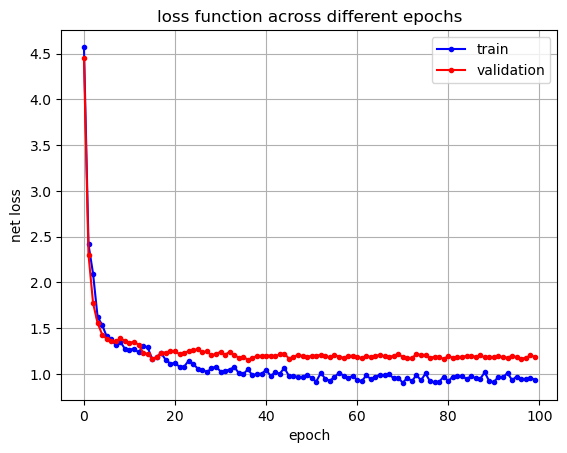

In [6]:
plt.plot(np.array(all_train_losses), color='blue', marker='.', label='train')
plt.plot(np.array(all_val_losses), color='red', marker='.', label='validation')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('net loss')
plt.title('loss function across different epochs')
plt.grid()

Text(0.5, 1.0, 'learning rate across different epochs')

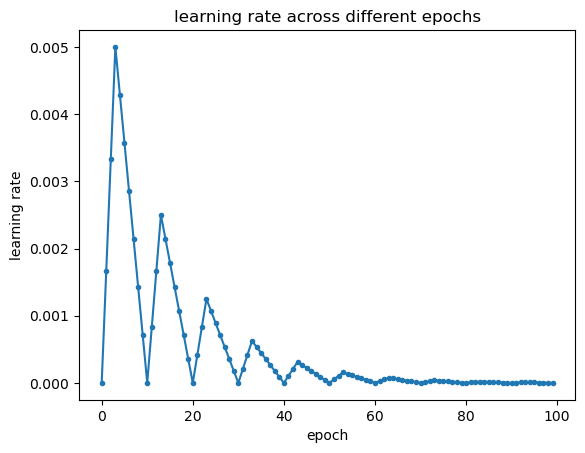

In [7]:
plt.plot(all_lrs, marker='.')
plt.xlabel('epoch')
plt.ylabel('learning rate')
plt.title('learning rate across different epochs')

In [8]:
# ## Inference on Test Sets and F1 scores
print("\nCalculating F1 scores on the validation set...")


Calculating F1 scores on the validation set...


In [ ]:
"""Loads a trained model and runs inference on the validation set."""
val_indices_path = os.path.join(config.MODEL_SAVE_DIR, 'validation_indices.npy')
    
val_indices = np.load(val_indices_path)

full_dataset = NeuronsDataset(config.DATA_DIR, data_transform(train=False))
dataset_val = torch.utils.data.Subset(full_dataset, val_indices)
data_loader_val = DataLoader(dataset_val, batch_size=1, shuffle=False, num_workers=config.NUM_TORCH_WORKERS, collate_fn=collate_fn)

perform_final_evaluation(model, config, device, plot_results=True)